In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

In [2]:
model = load_model(
    "../saved_models/best_finetuned_model.keras"
)

2026-05-29 22:28:59.689408: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-05-29 22:28:59.689729: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-29 22:28:59.689737: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-29 22:28:59.689991: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-29 22:28:59.694276: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

valid_dataset = valid_datagen.flow_from_directory(
    "../dataset/valid",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 17572 images belonging to 38 classes.


In [4]:
shuffle=False

In [5]:
predictions = model.predict(valid_dataset)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = valid_dataset.classes

2026-05-29 22:29:26.104573: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


550/550 ━━━━━━━━━━━━━━━━━━━━ 144s 252ms/step


In [6]:
print(predicted_classes.shape)
print(true_classes.shape)

(17572,)
(17572,)


In [7]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print(cm.shape)

(38, 38)


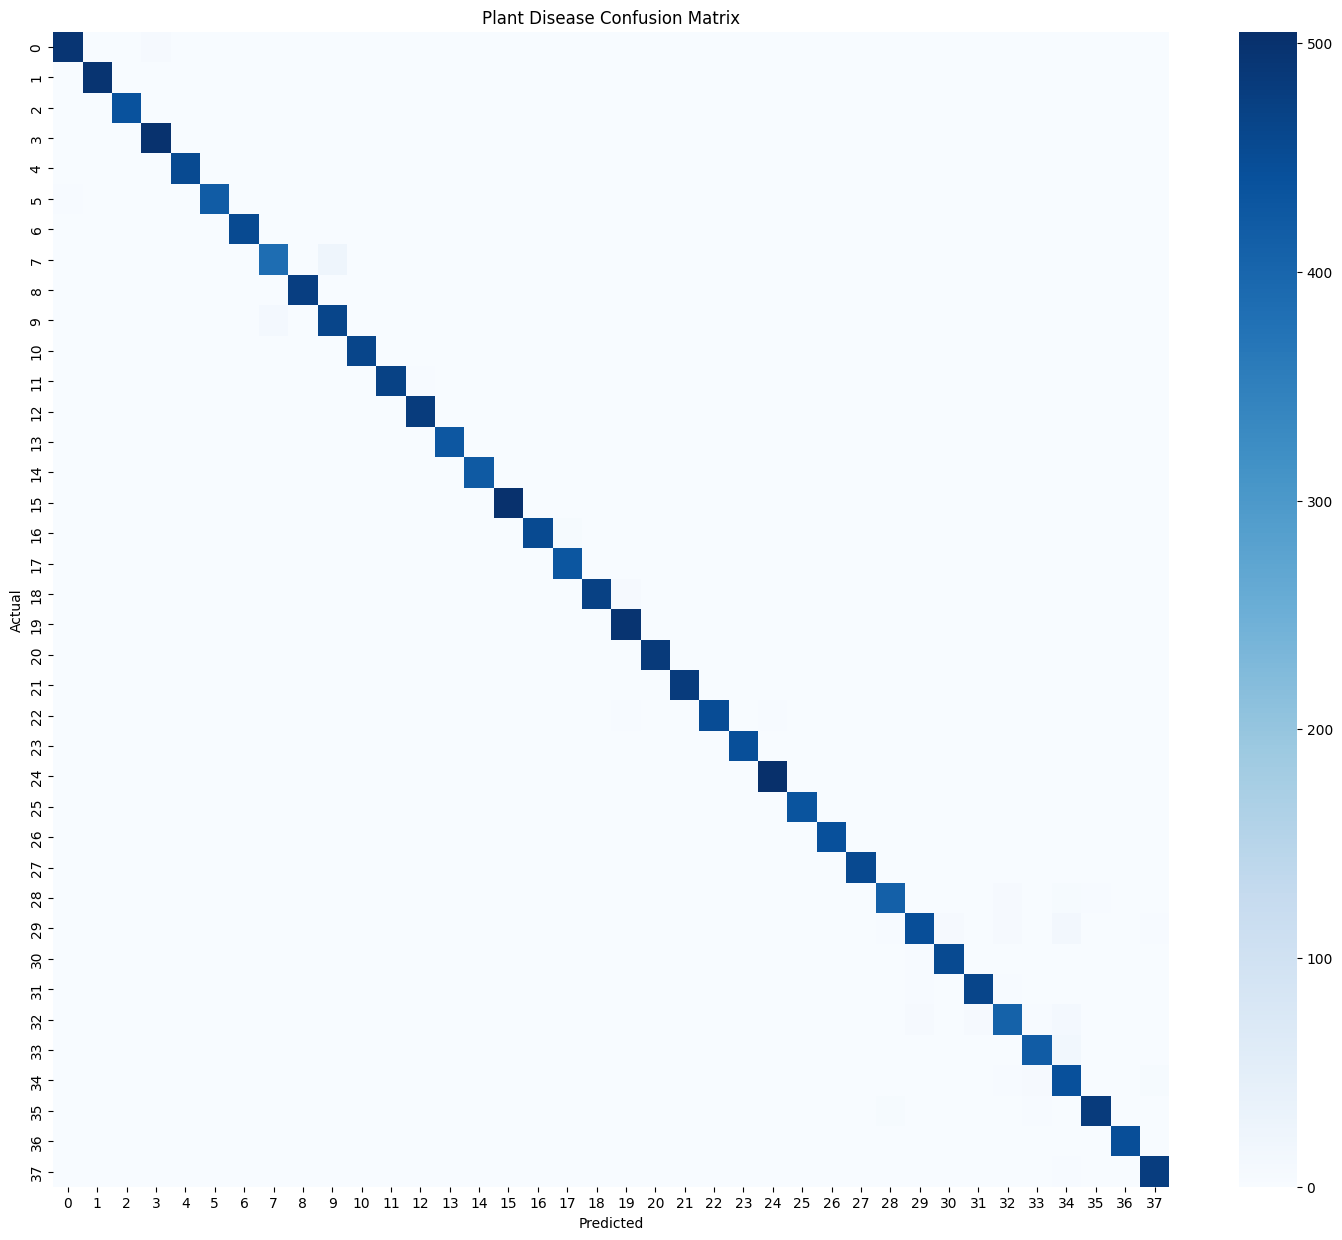

In [8]:
plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Plant Disease Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [9]:
class_names = list(
    valid_dataset.class_indices.keys()
)

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.98      0.99       504
                                 Apple___Black_rot       0.99      1.00      1.00       497
                          Apple___Cedar_apple_rust       1.00      1.00      1.00       440
                                   Apple___healthy       0.99      1.00      0.99       502
                               Blueberry___healthy       1.00      1.00      1.00       454
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       421
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.97      0.94      0.96       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.95      0.97      0.